<a href="https://colab.research.google.com/github/josedanielisidororeyes/Advanced_Data_Engineering/blob/main/Practica_1_Sistema_de_Recomendaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preperacion del entorno

In [ ]:
# Cargar de librerías
import pandas as pd
import matplotlib.pyplot as plt
!pip install kagglehub[pandas-datasets] -q
import kagglehub
import os
import seaborn as sns

In [ ]:
# Descarga de archivos desde Kaggle

path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")
print("Path to dataset files:", path)
dataset_path  = "/root/.cache/kagglehub/datasets/arashnic/book-recommendation-dataset/versions/3"

books  =  pd.read_csv(f"{dataset_path}/Books.csv", sep = ",", on_bad_lines  =  "skip", low_memory  =  False)
ratings = pd.read_csv(f'{dataset_path}/Ratings.csv', sep  = ",", encoding  =  "latin-1", on_bad_lines =  "skip")
users  =  pd.read_csv(f"{dataset_path}/Users.csv", sep =  ",", encoding  =  "latin-1", on_bad_lines =  "skip")


Using Colab cache for faster access to the 'book-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/book-recommendation-dataset


# Actividad 1. Inspección inicial

In [ ]:
# Inspección inicial books
print(books.info())
print()
books.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None



,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
# Inspección ratings
print(ratings.info())
print()
ratings.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
None



,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
# Inspección users
print(users.info())
print()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB
None



,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


Pregunta de análisis: ¿Qué representa una fila en cada tabla? ¿Qué columnas permiten relacionarlas?

La tabla de boks contiene las siguientes columnas

*   ISBN representa  un identificador único de cada libro
*   Book-Title representa el título del libro
*   Book-Author representa el autor del libro
*   Year-Of-Publication representa el año de publicación
*   Publisher representa  la editorial.

La tabla de Ratings incluye:

*   User-ID representa un identificador único del usuario que califó algún libro.
*   ISBN representa  un identificador único de cada libro
*   Book-Rating representa valoraciones explícitas e interaciones implicitas.

Finalmente, la tabla de usuario contiene:


*   User-ID representa un identificador único del usuario que califó algún libro.
*   Location representa la ubicación del usuario.
*   Age representa la edad del usuario.


La manera de relacionar las tablas es la siguiente:

Books y Ratings se relacionan a través de ISBN,
de tal manera que para cada libro se puede obtener sus valoraciones explicítas e interaciones implícitas por usuario.  

Ratings y Users se relacionan a través de UserID, esto es,  cada valoración e interaccion está asociada a un  usuario.


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


# Actividad 2. Calidad de los datos

##  Identificación Valores faltantes

In [ ]:
print("="*50)
print()
print("Valores faltantes por clumna tabla de libros\n")
print(books.isna().sum())
print()
print("="*50)
print()
print("Valores faltantes por columna  tabla de ratings\n")
print(ratings.isna().sum())
print()
print("="*50)
print()
print("Valores faltantes por columna tabla usarios\n")
print(users.isna().sum())
print()
print("="*50)



Valores faltantes por clumna tabla de libros

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


Valores faltantes por columna  tabla de ratings

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


Valores faltantes por columna tabla usarios

User-ID          0
Location         0
Age         110762
dtype: int64



## Identificación Valores duplicados

In [ ]:
# Identificación de valores faltantes
print("Valores duplicados tabla de libros: ", books.duplicated().sum())
print("Valores duplicados tabla de ratings: ", ratings.duplicated().sum())
print("Valores duplicados tabla de usuarios: ", users.duplicated().sum())

Valores duplicados tabla de libros:  0
Valores duplicados tabla de ratings:  0
Valores duplicados tabla de usuarios:  0


## Identificación interacciones usuario-libro repetidas

In [ ]:
interacciones_repetidas  = ratings.duplicated(subset =  ["User-ID", "ISBN"]).sum()
print("Número de interacciones usuario-libro repetidas: ", interacciones_repetidas)

Número de interacciones usuario-libro repetidas:  0


Pregunta de análisis: ¿Qué decisiones tomarías si encuentras una misma pareja usuario-libro más de una
vez?

**Respuesta**: Si el usuario y libro son los mismos, verificaría que las interacciones fueran diferentes. Si la información es la misma optaría por eliminar la información redundante.

# Actividad 3. Valoraciones explícitas e implícitas

In [ ]:
print(ratings["Book-Rating"].value_counts().sort_index())
explicit_ratings = ratings[
 ratings["Book-Rating"].between(1, 10)
].copy()
implicit_ratings = ratings[
 ratings["Book-Rating"] == 0
].copy()
print("Valoraciones explícitas:", len(explicit_ratings))
print("Interacciones implícitas:", len(implicit_ratings))


Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64
Valoraciones explícitas: 433671
Interacciones implícitas: 716109


# Actividad 4. Calcula número de usuarios, número de libros e interacciones

In [ ]:
num_users  =  ratings["User-ID"].nunique()
num_books =  ratings['ISBN'].nunique()
possible_interactions  =  num_users *  num_books
num_interactions  = len(explicit_ratings) +  len(implicit_ratings)


observed_percentage  =  (
    num_interactions / possible_interactions
) * 100

print("Interacciones posibles: ", possible_interactions)
print(f"Porcentaje observado:  {observed_percentage:.4f}%")


Interacciones posibles:  35854757348
Porcentaje observado:  0.0032%


Pregunta de análisis: ¿Qué indica un porcentaje de interacciones observadas muy pequeño?

**Respuesta**: Un procentaje bajo indica que la mayoría de libros no recibieron ninguna valoración. Es posible que las interacciones se estén concentrando en un subconjunto de libros pequeño, por ejemplo, lo más vendidos.

# Actividad 5: Calculo de la distribución de interacciones por usuario

Text(0, 0.5, 'Número de usuarios')

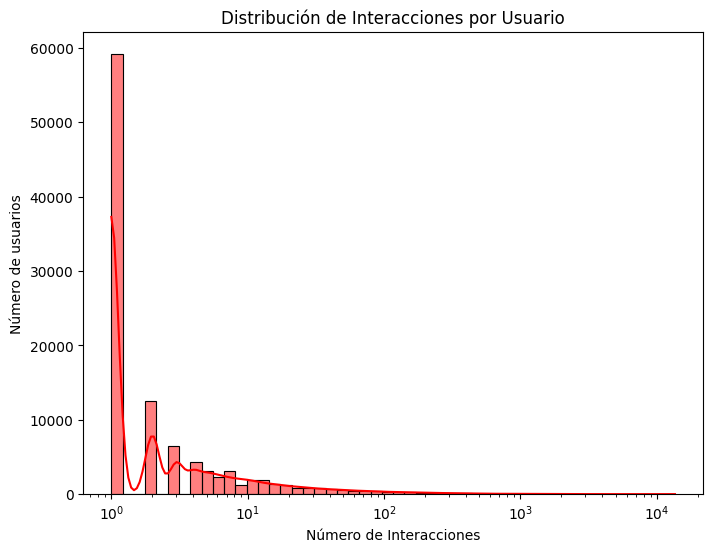

In [ ]:
user_interactions  = ratings["User-ID"].value_counts()

# Histograma
plt.figure(figsize  =  (8, 6))
sns.histplot(user_interactions, bins  =  50, kde =  True, log_scale  = True,  color =  "red")
plt.title("Distribución de Interacciones por Usuario")
plt.xlabel("Número de Interacciones")
plt.ylabel("Número de usuarios")


Pregunta de análisis: ¿Todos los usuarios aportan una cantidad similar de información?

**Respuesta**: No todos los usuarios aportan la misma cantidad de información, de hecho, se observa que la mayoría de usuarios regustraron solo una interacción, con algunos usuarios con muchas interacciones.


¿Cómo afectaría
esto a una recomendación personalizada?
**Respuesta**:
Para el caso de usuarios con muchas interacciones sería posible ofrecer recomendaciones personalizadas, no obstante, para el caso de usarios con pocas interacciones, una recomendación personalizada no sería adecuada porque no se contaría con suficiente información del comportamiento del usuario.

# Actividad 6. Cálculo de la popularidad de los libros

In [ ]:
popularidad =  (
    ratings.groupby('ISBN')['User-ID']
    .nunique()
    .reset_index(name='num_distinct_users')
    .sort_values(by  =  "num_distinct_users", ascending  =  False)
)
popularidad.merge(books[["ISBN", "Book-Title", "Book-Author"]], on  =  "ISBN")

,ISBN,num_distinct_users,Book-Title,Book-Author
0,0971880107,2502,Wild Animus,Rich Shapero
1,0316666343,1295,The Lovely Bones: A Novel,Alice Sebold
2,0385504209,883,The Da Vinci Code,Dan Brown
3,0060928336,732,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells
4,0312195516,723,The Red Tent (Bestselling Backlist),Anita Diamant
...,...,...,...,...
270146,0001047647,1,First Among Equals,Jeffrey Archer
270147,000104687X,1,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot
270148,0001046713,1,Twopence to Cross the Mersey,Helen Forrester
270149,0001046438,1,Liar,Stephen Fry


Pregunta de análisis: ¿Por qué es preferible contar usuarios distintos en lugar de contar únicamente filas?

**Respuesta**: Existe la posiblidad de que un usuario haya interactuado con el mismo libro varias veces, dando la impresión de que la popularidad es mayor.  Por ejemplo, un usuario podría haber interactuado implicitamente en primera instancia  y calificado en interacciones posteriores.

# Actividad 7. Calificación Promedio

In [ ]:
 (
    ratings[ratings["Book-Rating"] > 0].groupby('ISBN')['Book-Rating']
    .agg(
        calificacion_promedio  =  "mean",
        num_interacciones = "count"
    )
    .reset_index()
    .merge(books[["ISBN", "Book-Title", "Book-Author"]], on  =  "ISBN")
    .sort_values(by  = "calificacion_promedio", ascending  =  False)
    .head(5)
)

,ISBN,calificacion_promedio,num_interacciones,Book-Title,Book-Author
12,0001360469,10.0,1,Babe Dressing,Mandy Stanley
76698,0671737910,10.0,1,PENNY WHISTLE HALLOWEEN BOOK,Meredith Brokaw
76699,0671737929,10.0,1,Penny Whistle Party Planner,Meredith Brokaw
76709,0671738321,10.0,1,THEY CAN KILL YOU BUT THEY CAN'T EAT YOU: LESS...,Dawn Steel
25,0001900277,10.0,1,Glue (First Facts - First Skills),Harriet Hains


Pregunta de análisis: ¿Por qué una lista ordenada solamente por promedio puede colocar en primer lugar
a libros con muy pocas valoraciones?

**Respuesta**: Por qué no se están tomando en cuenta el número deinteracciones totales. Como se puede observar, los mejores libros son aquellos con apenas 1 interacción. Lo correcto, sería filtrar libros con cierto número de interacciones y después calcular el promedio

# Actividad 8: Recomendación no personalizada

In [ ]:
promedio_rating  =   explicit_ratings.groupby("ISBN")["Book-Rating"].agg(
    calificacion_promedio  = "mean",
    num_valoraciones  = "count"
).reset_index()

promedio_rating[promedio_rating["num_valoraciones"] >= 250].merge(books[["ISBN", "Book-Title", "Book-Author"]], on  =  "ISBN").sort_values(by  =  "calificacion_promedio", ascending  =  False)


,ISBN,calificacion_promedio,num_valoraciones,Book-Title,Book-Author
9,059035342X,8.939297,313,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling
1,0142001740,8.452769,307,The Secret Life of Bees,Sue Monk Kidd
5,0385504209,8.435318,487,The Da Vinci Code,Dan Brown
4,0316666343,8.185290,707,The Lovely Bones: A Novel,Alice Sebold
2,0312195516,8.182768,383,The Red Tent (Bestselling Backlist),Anita Diamant
7,0446672211,8.142373,295,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts
10,0671027360,8.100372,269,Angels &amp; Demons,Dan Brown
8,0452282152,7.982014,278,Girl with a Pearl Earring,Tracy Chevalier
0,0060928336,7.887500,320,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells
11,067976402X,7.808594,256,Snow Falling on Cedars,David Guterson


Se eligió un umbral de al menos 250 valoraciones explícitas con la finalidad de ofrecer una recomendación no personalizada respaldada por el consenso masivo de la comunidad lectora. Con este filtro se garantiza la creación de un top 10  confiable libre del sesgo de muestras pequeñas.

# Actividad 9. Mejora del promedio ponderado

In [ ]:
book_statistics =  explicit_ratings.groupby("ISBN")["Book-Rating"].agg(
    rating_mean  = "mean",
    rating_count =  "count"
).reset_index().merge(books[["ISBN", "Book-Title", "Book-Author"]], on  =  "ISBN")

C = explicit_ratings["Book-Rating"].mean()
m = 50

book_statistics["weighted_score"] = (
    (book_statistics["rating_count"] / (book_statistics["rating_count"] + m)) * book_statistics["rating_mean"]
    + (m / (book_statistics["rating_count"] + m)) * C
)

weighted_recommendations = (
    book_statistics[book_statistics["rating_count"] >= m]
    .sort_values("weighted_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(
    weighted_recommendations[
        [
            "Book-Title",
            "Book-Author",
            "rating_count",
            "rating_mean",
            "weighted_score"
        ]
    ]
)

,Book-Title,Book-Author,rating_count,rating_mean,weighted_score
0,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,137,9.262774,8.818467
1,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,313,8.939297,8.754968
2,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,206,9.033981,8.754115
3,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,77,9.402597,8.693333
4,To Kill a Mockingbird,Harper Lee,214,8.943925,8.689596
5,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,133,9.082707,8.677887
6,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,141,9.035461,8.659965
7,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,119,8.983193,8.574280
8,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,83,9.120482,8.549273
9,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,126,8.920635,8.545757


Pregunta de análisis: ¿Qué diferencias observas entre la lista ordenada por promedio simple y la lista
ordenada por promedio ponderado?

**Respuesta**:  Se observa que el promedio simple tiende a sobrestimar la calificación promedio. En cambio, el promedio ponderado beneficia a libros con mayor número de interacciones explicítias.

# Preguntas de reflexión final

¿La lista obtenida es una recomendación personalizada? Explica por qué.

**Respuesta**:

¿Qué usuarios recibirían exactamente la misma lista?

**Respuesta**:

¿Qué diferencia existe entre un libro popular y un libro bien evaluado?

**Respuesta**:

¿Qué efecto tienen las calificaciones implícitas con valor cero?

**Respuesta**:

¿Qué problema enfrentan los libros nuevos o con pocas valoraciones?

**Respuesta**:

¿Qué sesgo puede producir recomendar principalmente los libros más populares?

**Respuesta**:

¿Qué información sería necesaria para generar recomendaciones distintas para cada usuario?

**Respuesta**:

¿Qué limitaciones encontraste en la calidad o estructura de Book-Crossing?

**Respuesta**: